## 0. Loading

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create directories if they don't exist
os.makedirs('./data', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Setup complete.")

# Load all CSV files
print("Loading data files...")

df = pd.read_csv('./data/CDC Diabetes Dataset.csv')
print(f"CDC Diabetes Dataset: {df.shape}")

print("\nData loading complete.")

Setup complete.
Loading data files...
CDC Diabetes Dataset: (253680, 22)

Data loading complete.


## 1. Data Preparation

In [2]:
cluster_features = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',  
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'DiffWalk',
    'Sex',
    'Age',
]


In [3]:
## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster = df[cluster_features]
X_cluster_scaled = RobustScaler().fit_transform(X_cluster)

## 2. K-Means

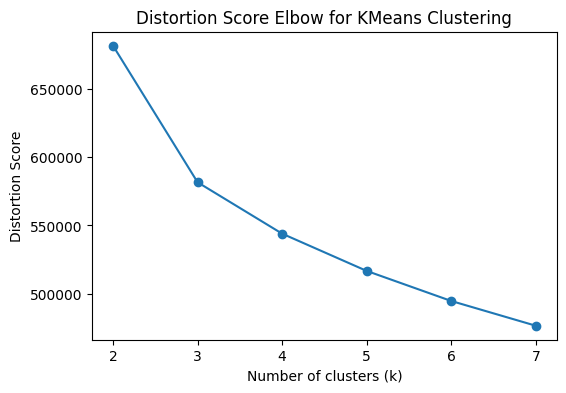

In [4]:
from sklearn.cluster import KMeans

inertias = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()


Silhouette scores for different k values:

k = 2 | silhouette score = 0.1832
k = 3 | silhouette score = 0.1581
k = 4 | silhouette score = 0.1248
k = 5 | silhouette score = 0.1186
k = 6 | silhouette score = 0.1112
k = 7 | silhouette score = 0.1105


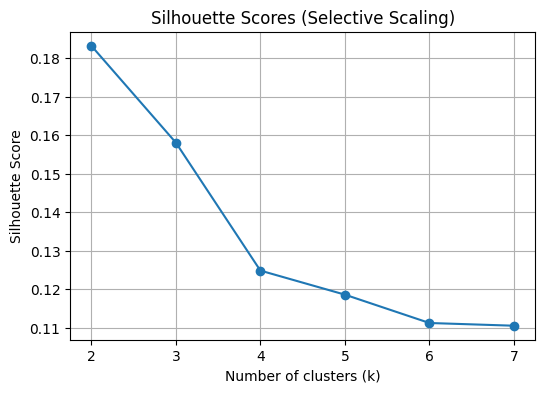

In [5]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled, labels, sample_size=20000, random_state=42)
    sil_scores.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

Silhouette score method indicates the best options would be 2, 3 or 4 clusters. Start with 3 clusters and check interpretability. 

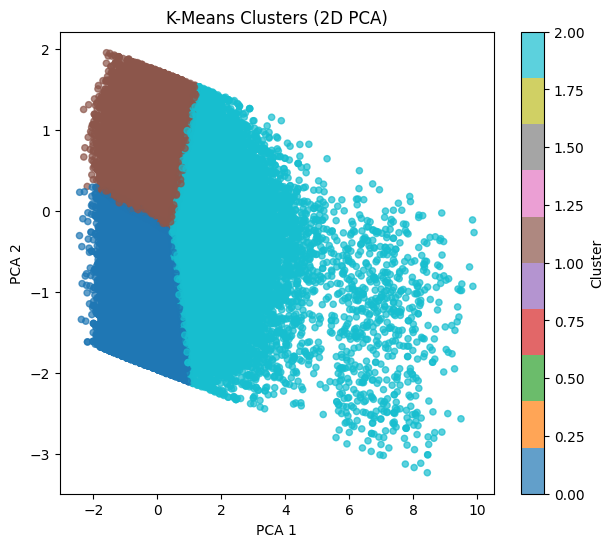

In [28]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df['cluster'] = clusters

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA)")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                     PC1    PC2
BMI                0.963 -0.149
HighBP             0.174  0.297
DiffWalk           0.108  0.123
HighChol           0.105  0.258
PhysActivity      -0.098 -0.075
Fruits            -0.067  0.035
Age                0.048  0.886
Veggies           -0.042 -0.013
Sex                0.033 -0.014
Smoker             0.031  0.129
HvyAlcoholConsump -0.012 -0.005


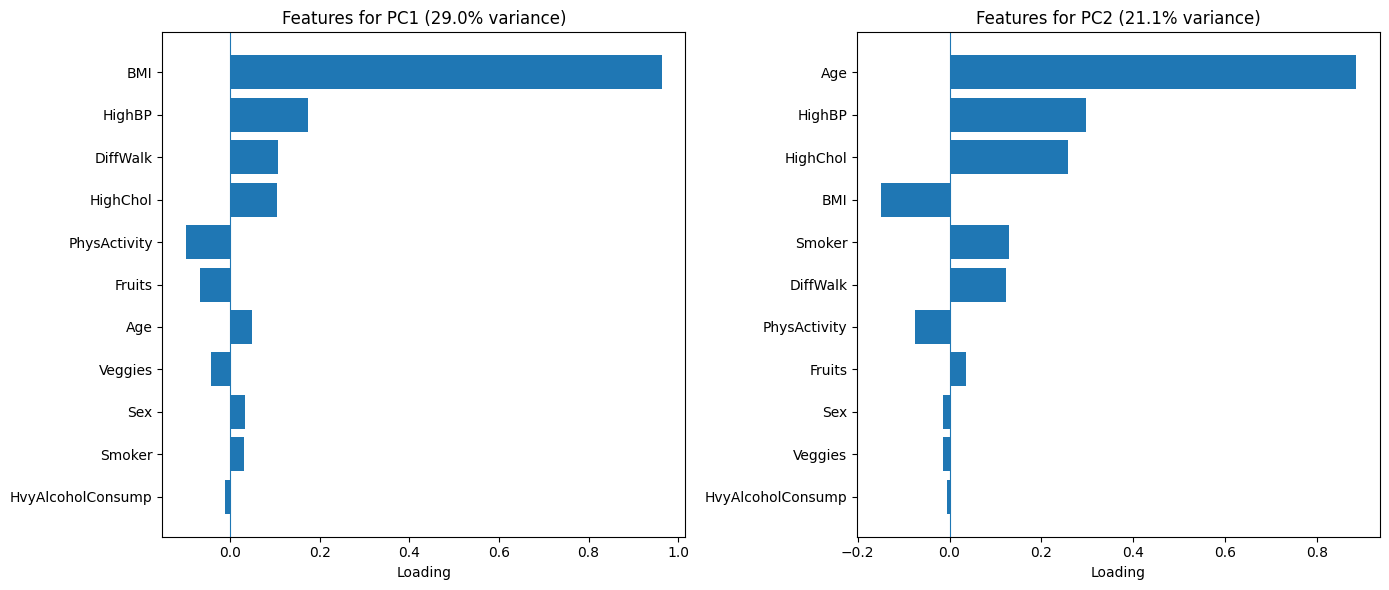

In [26]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [27]:
df.groupby('cluster')[cluster_features].mean().round(3)

,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
cluster,,,,,,,,,,,
0,0.590,0.584,26.354,0.527,0.748,0.663,0.810,0.057,0.198,0.454,10.293
1,0.652,0.526,38.638,0.465,0.597,0.533,0.751,0.037,0.343,0.419,7.755
2,0.106,0.164,25.813,0.322,0.849,0.648,0.844,0.065,0.040,0.433,5.226


C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\3796606850.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


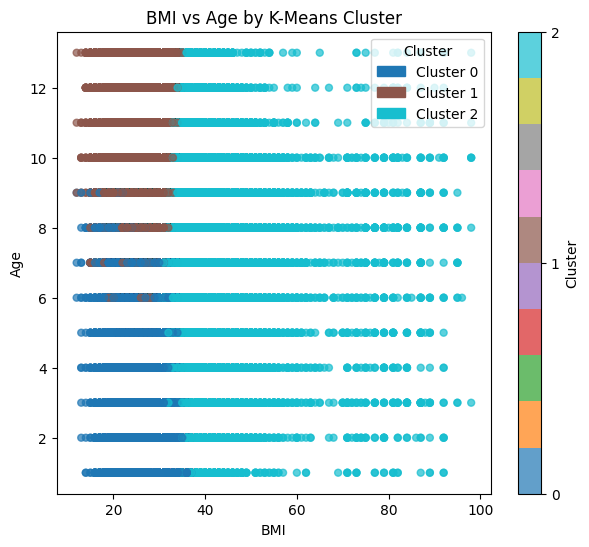

In [9]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['BMI'],
    df['Age'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('Age')
plt.title('BMI vs Age by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\3177251008.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


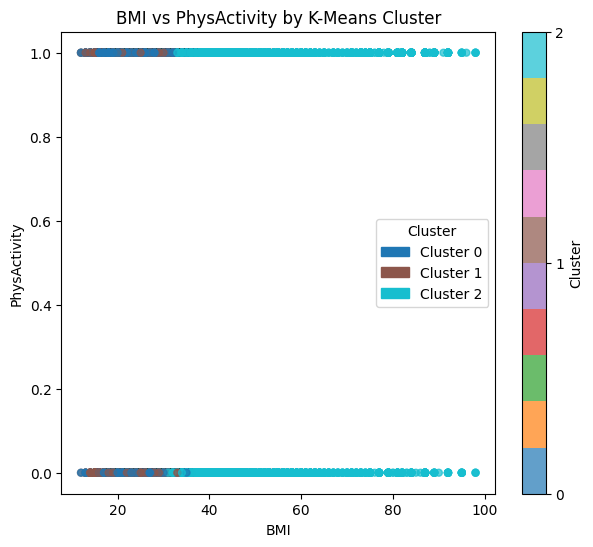

In [10]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['BMI'],
    df['PhysActivity'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('PhysActivity')
plt.title('BMI vs PhysActivity by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\1565611120.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


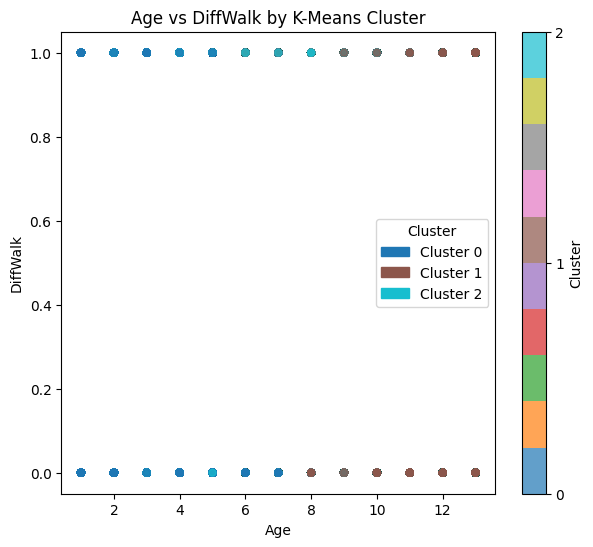

In [11]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['Age'],
    df['DiffWalk'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('Age')
plt.ylabel('DiffWalk')
plt.title('Age vs DiffWalk by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

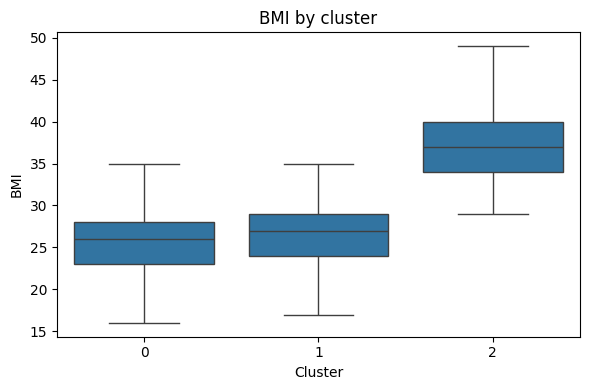

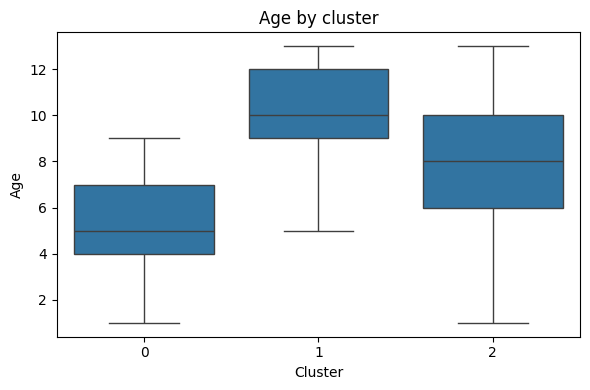

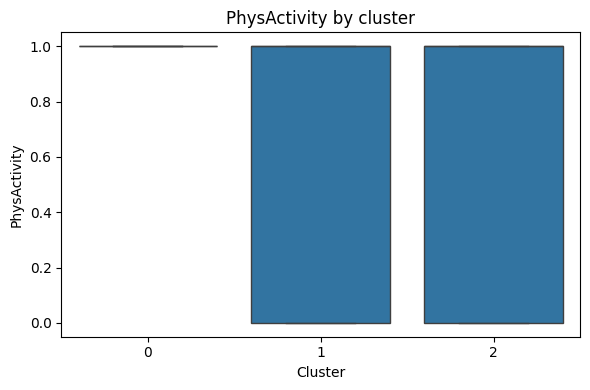

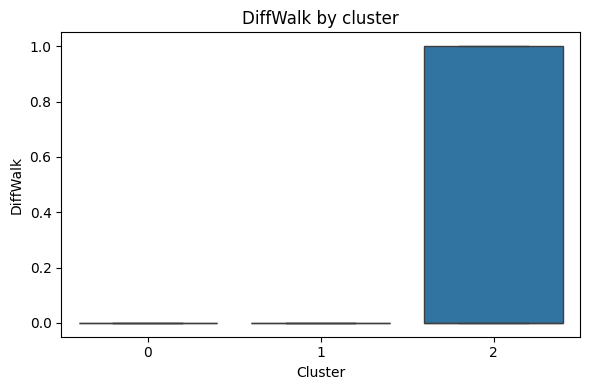

In [12]:
import seaborn as sns
features = ['BMI', 'Age', 'PhysActivity', 'DiffWalk']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x='cluster',
        y=feature,
        data=df,
        showfliers=False
    )
    plt.title(f'{feature} by cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## 3. GMM

In [13]:
from sklearn.mixture import GaussianMixture

# 1) random sampling (fixed seed for reproducibility)
rng = np.random.RandomState(42)
n = X_cluster_scaled.shape[0]
sample_size = min(20000, n)   # 1-2万足够选k
idx = rng.choice(n, size=sample_size, replace=False)
X_s = X_cluster_scaled[idx]

# 2) fit GMM with different k and compute BIC/AIC
k_range = range(2, 9)
bics, aics = [], []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        reg_covar=1e-6,
        init_params='kmeans',
        n_init=3,
        max_iter=300,
        random_state=42
    )
    gmm.fit(X_s)
    bics.append(gmm.bic(X_s))
    aics.append(gmm.aic(X_s))

print("BIC:", list(zip(k_range, bics)))
print("AIC:", list(zip(k_range, aics)))

BIC: [(2, 71041.40579142988), (3, -66299.52018653572), (4, -187523.2186113362), (5, -250282.55843125962), (6, -382740.5161939625), (7, -412284.4741042599), (8, -390642.5527369403)]
AIC: [(2, 70685.74885156575), (3, -66836.95734010817), (4, -188242.435978617), (5, -251183.55601224874), (6, -383823.2939886599), (7, -413549.0321126657), (8, -392088.89095905446)]


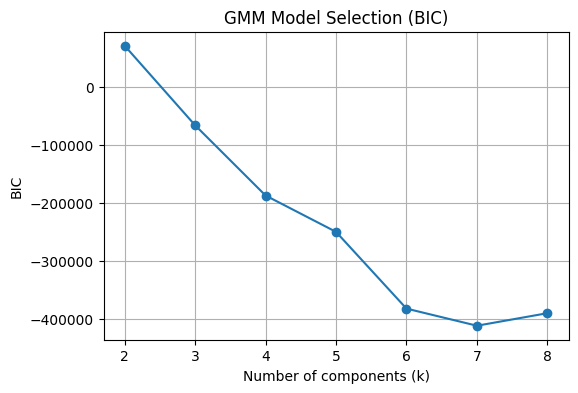

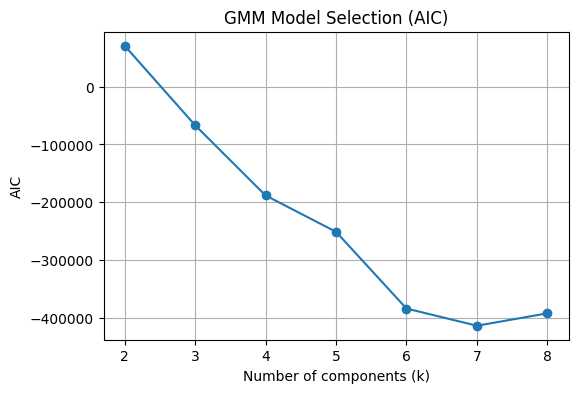

In [14]:
plt.figure(figsize=(6,4))
plt.plot(list(k_range), bics, marker='o')
plt.xlabel("Number of components (k)")
plt.ylabel("BIC")
plt.title("GMM Model Selection (BIC)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(k_range), aics, marker='o')
plt.xlabel("Number of components (k)")
plt.ylabel("AIC")
plt.title("GMM Model Selection (AIC)")
plt.grid(True)
plt.show()


In [15]:
best_k = k_range[int(np.argmin(bics))]
print(f"Best k according to BIC: {best_k}")
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_s, GaussianMixture(
    n_components=best_k, covariance_type='diag',
    reg_covar=1e-6, init_params='kmeans', n_init=3,
    max_iter=300, random_state=42
).fit(X_s).predict(X_s))

print("Silhouette (subsample) =", sil)


Best k according to BIC: 7
Silhouette (subsample) = 0.08370362593557995


In [16]:
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    reg_covar=1e-6,
    init_params='kmeans',
    n_init=5,
    max_iter=500,
    random_state=42
)
gmm_final.fit(X_cluster_scaled)

labels_gmm = gmm_final.predict(X_cluster_scaled)
proba_gmm  = gmm_final.predict_proba(X_cluster_scaled)
df['cluster_gmm'] = labels_gmm
df['gmm_max_prob'] = proba_gmm.max(axis=1)

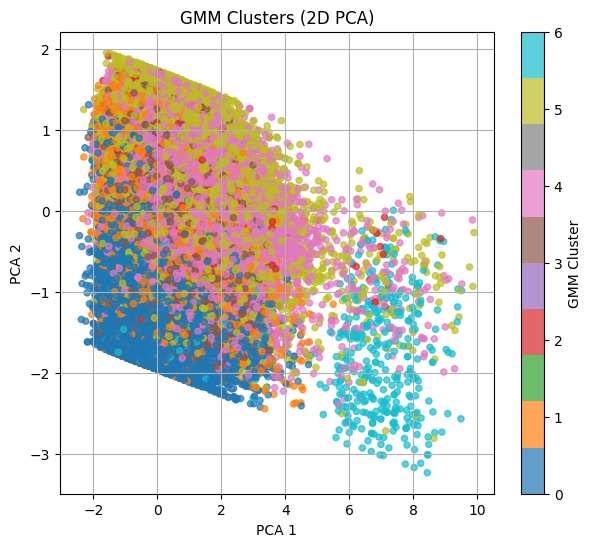

In [17]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=df['cluster_gmm'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("GMM Clusters (2D PCA)")
plt.colorbar(label="GMM Cluster")
plt.grid(True)
plt.show()

PCA Loadings (Feature Contributions):
                     PC1    PC2
BMI                0.963 -0.149
HighBP             0.174  0.297
DiffWalk           0.108  0.123
HighChol           0.105  0.258
PhysActivity      -0.098 -0.075
Fruits            -0.067  0.035
Age                0.048  0.886
Veggies           -0.042 -0.013
Sex                0.033 -0.014
Smoker             0.031  0.129
HvyAlcoholConsump -0.012 -0.005


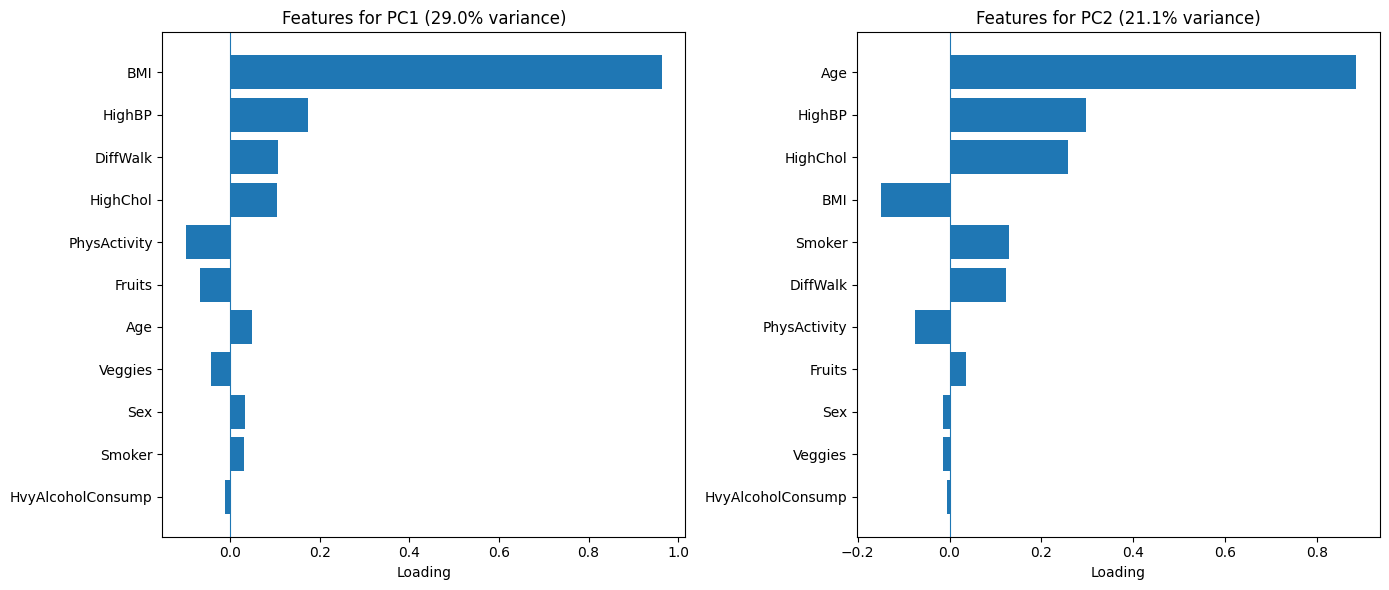

In [18]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings2 = pd.DataFrame(
    pca2.components_.T,
    columns=[f"PC{i+1}" for i in range(pca2.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted_pc2 = loadings2.reindex(loadings2["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted_pc2.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted_pc2["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted_pc2.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings2.reindex(loadings2["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [19]:
df.groupby('cluster_gmm')[cluster_features].mean().round(3)

,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
cluster_gmm,,,,,,,,,,,
0,0.000,0.000,26.747,0.343,0.807,0.612,0.812,0.000,0.000,0.497,5.999
1,0.450,0.502,27.064,0.402,1.000,0.805,1.000,0.096,0.000,0.000,8.894
2,1.000,0.596,29.005,0.748,0.291,0.455,0.693,1.000,0.448,0.521,8.887
3,0.673,0.680,28.635,0.498,1.000,0.612,0.815,0.093,0.000,1.000,8.484
4,0.699,0.655,31.076,0.560,0.338,0.000,0.540,0.000,0.528,0.396,8.813
5,0.691,0.618,30.439,0.499,0.416,1.000,0.772,0.000,0.615,0.334,9.482
6,0.000,0.292,34.787,0.662,0.364,0.457,0.671,0.863,0.217,0.408,6.847


C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\3830696905.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


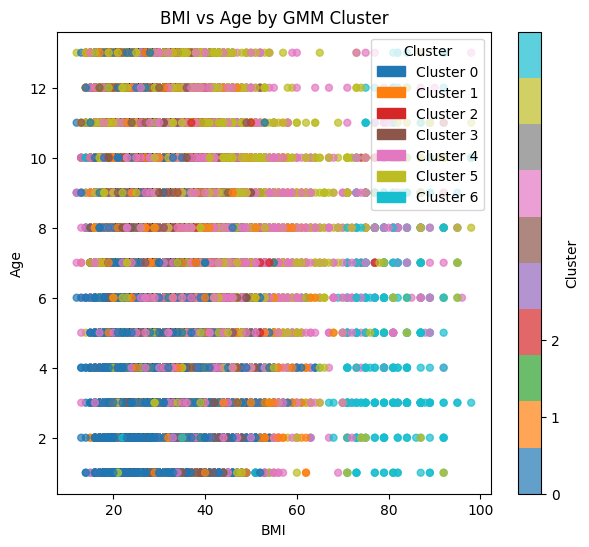

In [20]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['BMI'],
    df['Age'],
    c=df['cluster_gmm'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('Age')
plt.title('BMI vs Age by GMM Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster_gmm'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\412426262.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


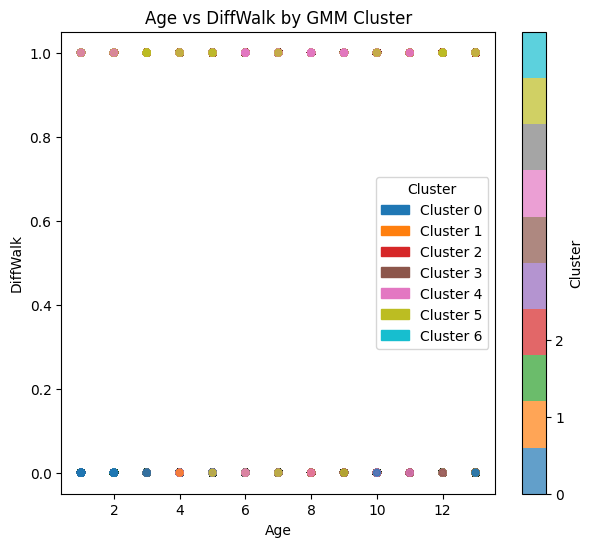

In [21]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['Age'],
    df['DiffWalk'],
    c=df['cluster_gmm'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('Age')
plt.ylabel('DiffWalk')
plt.title('Age vs DiffWalk by GMM Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster_gmm'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\550549223.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


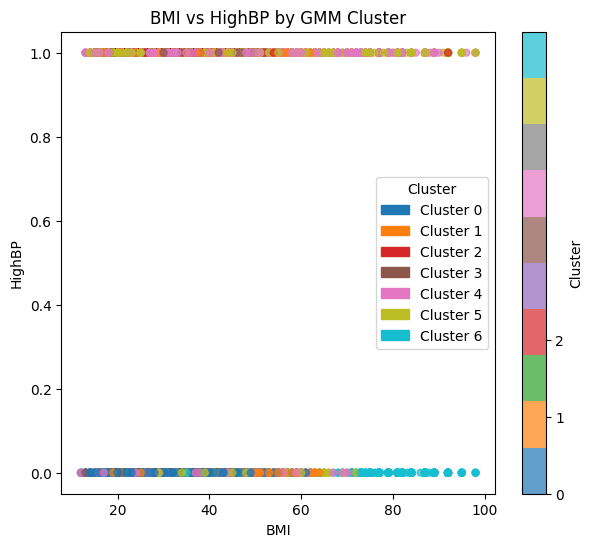

In [22]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['BMI'],
    df['HighBP'],
    c=df['cluster_gmm'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('HighBP')
plt.title('BMI vs HighBP by GMM Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster_gmm'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_15948\2252646402.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


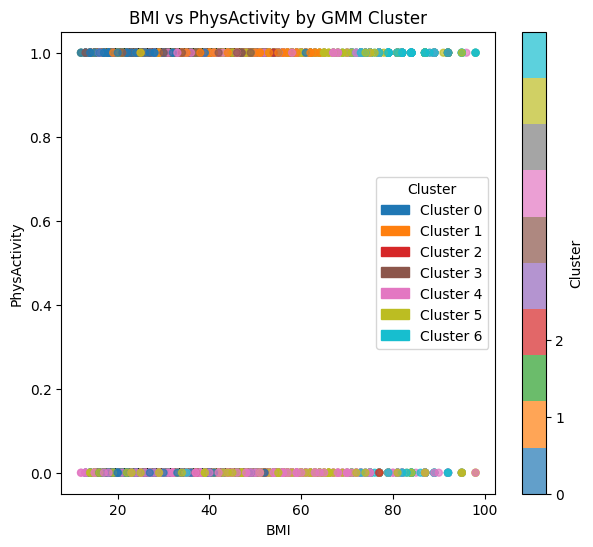

In [23]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['BMI'],
    df['PhysActivity'],
    c=df['cluster_gmm'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('PhysActivity')
plt.title('BMI vs PhysActivity by GMM Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster_gmm'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

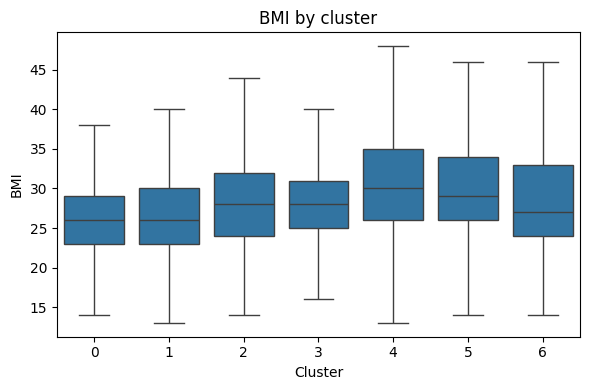

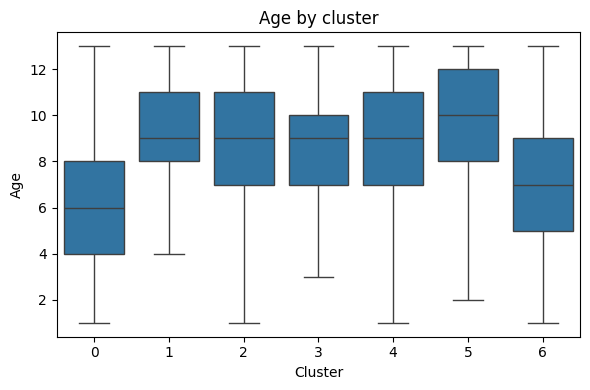

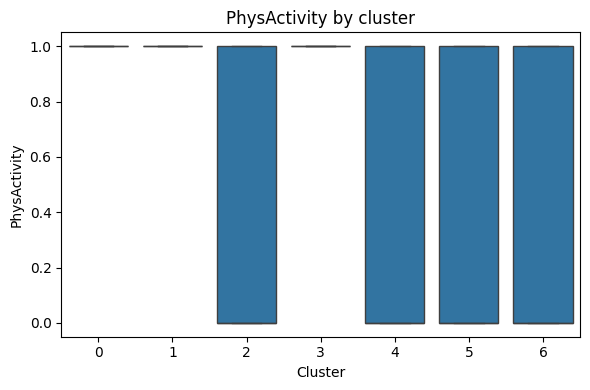

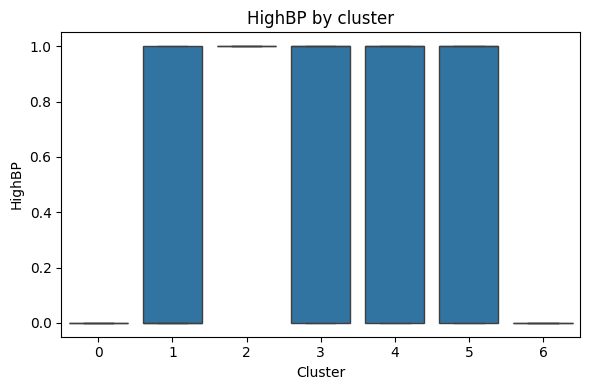

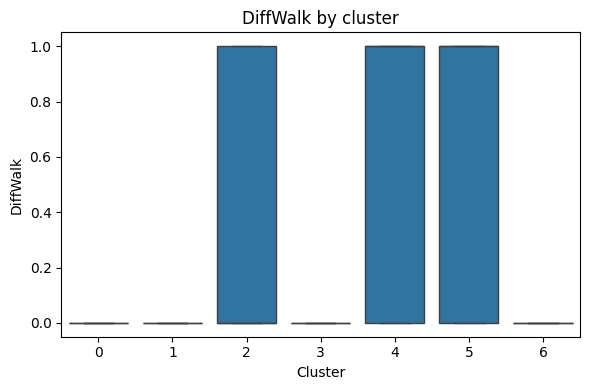

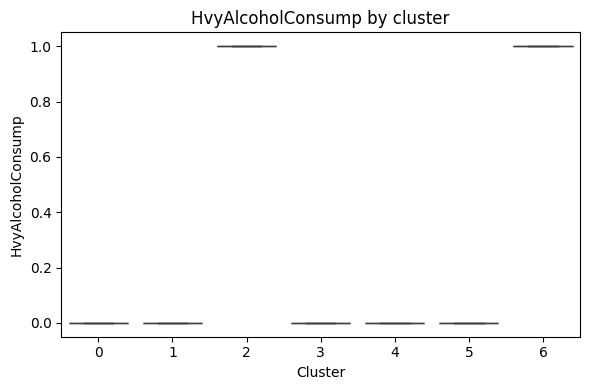

In [24]:
import seaborn as sns
features = ['BMI', 'Age', 'PhysActivity', 'HighBP', 'DiffWalk', 'HvyAlcoholConsump']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x='cluster_gmm',
        y=feature,
        data=df,
        showfliers=False
    )
    plt.title(f'{feature} by cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()